---
draft: true
---

# KL divergence and f-Divergence

## Motivation and definition

Let's consider KL divergence and f-Divergence in the context of AI/ML. In AI/ML, we often have a real-world probability distribution $P(x_i)$ that we are modelling with $Q(x_i)$. A concrete example is when we are training LLMs to model human language. In this example, $P(x_i)$ is human language and $Q(x_i)$ is the LLM.

Can we measure the difference between the two distributions?

There are different metrics that we can use, but KL divergence is one of the most popular ones, if not the most important. KL divergence can be thought of as the average number of extra bytes it takes to encode information from $P$ using $Q$. Concretely, it is defined as:

$$D_{KL}(P || Q) := -p(x_i)\log q(x_i) + p(x_i)\log p(x_i)$$

In this article, I will use Einstein notation and work with discrete probability distributions to keep the maths simple. The same argument can be applied to continuous probability distributions as well.

In reality, this expression is almost impossible to compute directly. Often we have control over $Q(x_i)$ not $P(x_i)$, for example, we can do agent rollout with our LLM $Q(x_i)$ not with the real human language $P(x_i)$. Therefore, often it is better to write this expression as:

$$D_{KL}(P || Q) := q(x_i) \frac{p(x_i)}{q(x_i)}\log \frac{p(x_i)}{q(x_i)} = \mathbb{E}_Q [r\log r]$$

where we introduced a shorthand notation $r:=p/q$. This is where we can link to f-Divergence.

$$D_{f}(P||Q) := \mathbb{E}_Q\left[f(r)\right],$$

where $f$ is convex and $f(1)=0$. 

f-Divergence enjoys a great deal of nice properties; for example, f-Divergence is always greater than or equal to zero. This makes it suitable to use as a loss function in training. To close out this section, we can plot the KL-divergence f-function which is $r\log r$ to confirm it is indeed convex and $f(1) = 0$:

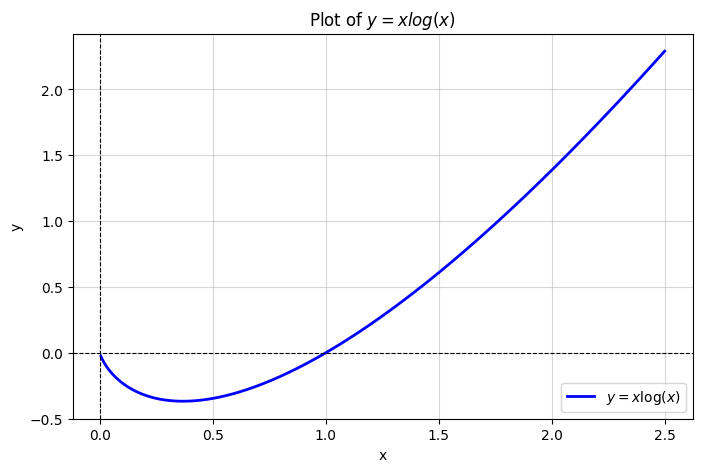

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Generate x values from -1 to 5
# We use 500 points for a smooth curve
x = np.linspace(0, 2.5, 500)

# 2. Calculate y values
# We use np.errstate to suppress the expected warnings for x <= 0
with np.errstate(divide='ignore', invalid='ignore'):
    y = x * np.log(x) 

# 3. Create the plot
plt.figure(figsize=(8, 5))
plt.plot(x, y, label=r'$y = x \log(x)$', color='blue', linewidth=2)

# 4. Add styling for readability
plt.axhline(0, color='black', linewidth=0.8, linestyle='--') # x-axis
plt.axvline(0, color='black', linewidth=0.8, linestyle='--') # y-axis
plt.title('Plot of $y = x log(x)$')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.5)
plt.legend()

# 5. Display the plot
plt.show()

## Forward and reverse KL

Mathematically, $P(x)$ and $Q(x)$ are probability distributions and there is no "privilege" between the two. However, in AI/ML, $P(x)$ is the real distribution and $Q(x)$ is the model distribution, or $P(x)$ is the teacher model and $Q(x)$ is the student model. We implicitly give $P(x)$ the privilege in AI/ML. This leads to the notion of forward KL and reverse KL divergence. Forward KL is the KL divergence that is defined in statistics, and reverse KL is with the arguments reversed. Concretely:

$$
\begin{aligned}
D_{KL-\text{forward}}(P||Q) & := \mathbb{E}_Q [r\log r] \\
D_{KL-\text{reverse}}(Q||P) & := \mathbb{E}_Q [-\log r]
\end{aligned}
$$

We can check that the reverse KL f-function is also convex, and satisfies $f(1)=0$:

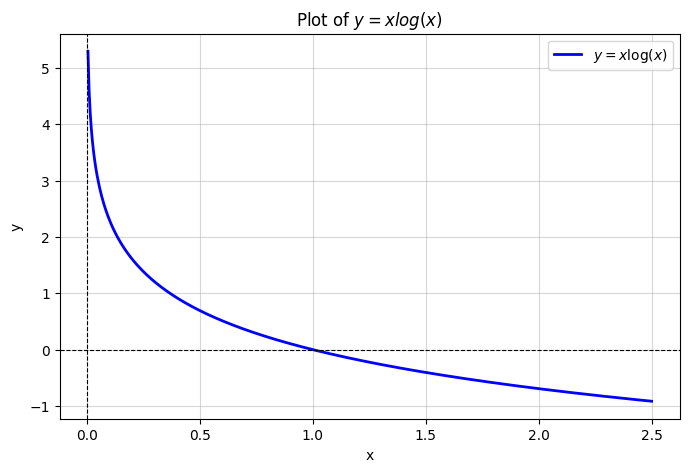

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Generate x values from -1 to 5
# We use 500 points for a smooth curve
x = np.linspace(0, 2.5, 500)

# 2. Calculate y values
# We use np.errstate to suppress the expected warnings for x <= 0
with np.errstate(divide='ignore', invalid='ignore'):
    y = - np.log(x) 

# 3. Create the plot
plt.figure(figsize=(8, 5))
plt.plot(x, y, label=r'$y = x \log(x)$', color='blue', linewidth=2)

# 4. Add styling for readability
plt.axhline(0, color='black', linewidth=0.8, linestyle='--') # x-axis
plt.axvline(0, color='black', linewidth=0.8, linestyle='--') # y-axis
plt.title('Plot of $y = x log(x)$')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.5)
plt.legend()

# 5. Display the plot
plt.show()

Note that $\lim_{r\rightarrow 0} -\log r = \infty$. This leads to behaviour that people call mode-seeking. If we were to use reverse KL as our loss function, the model $Q(x)$ does everything in its power to avoid making $r(x) = p(x) / q(x)$ approach zero. In other words, when $p(x)$ is small, $q(x)$ must also be small, which forces the distribution to avoid spreading out wide, and avoids assigning any probability to regions where $p(x)$ is small.

To contrast with this behaviour, often people say training on forward KL is mean-seeking, where $Q(x)$ will spread across to cover $P(x)$ as much as possible.

## Estimating forward and reverse KL

In real life, we often cannot compute the probability distribution exactly, but only sample from it. How can we estimate forward and reverse KL with just a sample of the distribution? Recall that the f-functions for forward and reverse KL are:

$$
\begin{aligned}
f_{\text{forward}}(r) & := r\log r \\
f_{\text{reverse}}(r) & := -\log r
\end{aligned}
$$

Evaluating these functions directly and computing the expectation will eventually give us the correct answer, but note that the functions can produce negative values, while KL divergence is always non-negative. In other words, these function estimates are unbiased but have high variance. A classic solution to adjusting the variance is to add a term that has an expected value of zero but can correct the early behaviour with small samples. In this case, we want to correct the behaviour where using the f-functions directly can produce negative numbers. We have one natural quantity whose expected value is zero: $\mathbb{E}_Q[r-1] = 0$. We can add this to the f-functions with a multiplier $\lambda$:

$$
\begin{aligned}
\tilde{f}_{\text{forward}}(r) & := r\log r + \lambda_1 (r - 1) \\
\tilde{f}_{\text{reverse}}(r) & := -\log r + \lambda_2 (r - 1)
\end{aligned}
$$

Now the task is to pick $\lambda_1$ and $\lambda_2$ so that the modified $\tilde{f}$ function will always be non-negative. We can eyeball the solution from looking at the graph or taking the derivative to find $\lambda$ like in the Lagrange multiplier method. In our case, the solution is almost readable from the graph:

$$
\begin{aligned}
\tilde{f}_{\text{forward}}(r) & := r\log r - (r - 1) \\
\tilde{f}_{\text{reverse}}(r) & := -\log r + (r - 1)
\end{aligned}
$$

Here is an explicit computation to compare $f$ and $\tilde{f}$:

In [14]:
import torch.distributions as dis

p = dis.Normal(loc=0, scale=1)
q = dis.Normal(loc=0.1, scale=1)
x = q.sample(sample_shape=(10_000_000,))

true_kl = dis.kl_divergence(p, q)
logr = p.log_prob(x) - q.log_prob(x)

forward = logr.exp() * logr - (logr.exp() - 1)
reverse = -logr + (logr.exp() - 1)

print(f"{true_kl=}")
print(f"{forward.mean()=} {forward.std()=}")
print(f"{reverse.mean()=} {reverse.std()=}")

true_kl=tensor(0.0050)
forward.mean()=tensor(0.0050) forward.std()=tensor(0.0072)
reverse.mean()=tensor(0.0050) reverse.std()=tensor(0.0071)


## Example: Fitting a single Gaussian to a Bimodal Gaussian Mixture

A classic and very effective example to illustrate this is fitting a single Gaussian distribution to a bimodal Gaussian mixture (a distribution with two peaks). 

Here is how it works conceptually:
- **True Distribution ($P$):** A mixture of two Gaussians (e.g., one peak at $x=-2$ and another at $x=2$).
- **Model Distribution ($Q$):** A single Gaussian parameterized by its mean ($\mu$) and standard deviation ($\sigma$).

When you train $Q$ to match $P$:
1. **Forward KL ($D_{KL}(P||Q)$ - Mean-Seeking):** The model $Q$ must avoid making $q(x)$ small where $p(x)$ is large (since $p \log(p/q)$ blows up if $q \to 0$). Therefore, the single Gaussian spreads out wide to cover *both* peaks, placing its mean in the middle (around $x=0$) even though $P$ has very low probability there.
2. **Reverse KL ($D_{KL}(Q||P)$ - Mode-Seeking):** The model $Q$ must avoid placing probability mass where $P$ has none (since $q \log(q/p)$ blows up if $p \to 0$). To avoid the "valley" between the two peaks, the single Gaussian collapses onto just *one* of the peaks and completely ignores the other.

Here is some PyTorch/Matplotlib code to demonstrate this visually:

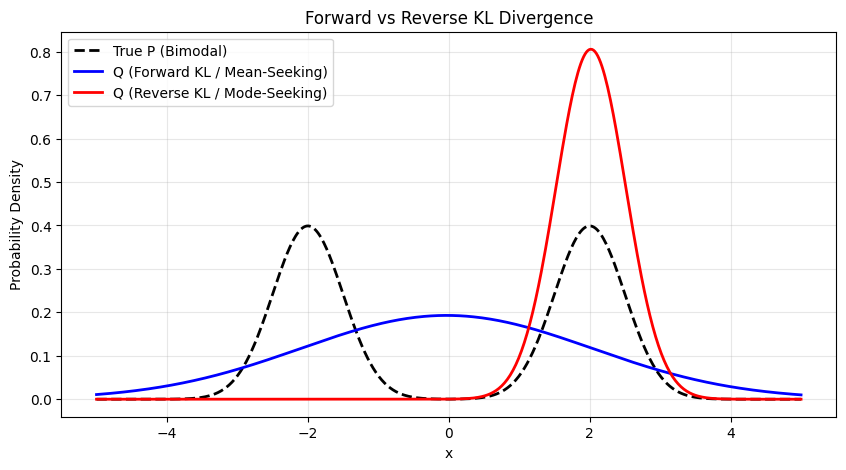

In [2]:
import torch
import torch.distributions as dist
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Define the true distribution P (Bimodal Gaussian Mixture)
mix = dist.Categorical(torch.tensor([0.5, 0.5]))
comp = dist.Normal(torch.tensor([-2.0, 2.0]), torch.tensor([0.5, 0.5]))
P = dist.MixtureSameFamily(mix, comp)

# 2. Setup the models Q (Single Gaussians) to be trained
# One for Forward KL, one for Reverse KL
# We initialize slightly off-center to avoid the exact saddle point at 0.0
mean_fwd = nn.Parameter(torch.tensor([1.0]))
log_std_fwd = nn.Parameter(torch.tensor([0.0]))

mean_rev = nn.Parameter(torch.tensor([1.0]))
log_std_rev = nn.Parameter(torch.tensor([0.0]))

opt_fwd = optim.Adam([mean_fwd, log_std_fwd], lr=0.05)
opt_rev = optim.Adam([mean_rev, log_std_rev], lr=0.05)

# 3. Training loop
epochs = 1000
for _ in range(epochs):
    # Sample from P and Q
    x_p = P.sample((1000,))
    
    Q_fwd = dist.Normal(mean_fwd, log_std_fwd.exp())
    Q_rev = dist.Normal(mean_rev, log_std_rev.exp())
    
    x_q_rev = Q_rev.rsample((1000,)) # Reparameterization trick for gradient flow
    
    # Forward KL Loss: D_KL(P || Q) = E_P[-log Q(x)] - H(P)
    # Minimizing it is equivalent to minimizing E_P[-log Q(x)]
    loss_fwd = -Q_fwd.log_prob(x_p).mean()
    
    # Reverse KL Loss: D_KL(Q || P) = E_Q[log Q(x) - log P(x)]
    # We use exact entropy here to avoid zero-gradient issues with the reparameterization trick
    loss_rev = -Q_rev.entropy() - P.log_prob(x_q_rev).mean()
    
    # Optimization steps
    opt_fwd.zero_grad()
    loss_fwd.backward()
    opt_fwd.step()
    
    opt_rev.zero_grad()
    loss_rev.backward()
    opt_rev.step()

# 4. Plotting the results
x = torch.linspace(-5, 5, 500)
with torch.no_grad():
    y_p = P.log_prob(x).exp()
    Q_fwd_final = dist.Normal(mean_fwd, log_std_fwd.exp())
    y_q_fwd = Q_fwd_final.log_prob(x).exp()
    
    Q_rev_final = dist.Normal(mean_rev, log_std_rev.exp())
    y_q_rev = Q_rev_final.log_prob(x).exp()

plt.figure(figsize=(10, 5))
plt.plot(x.numpy(), y_p.numpy(), label='True P (Bimodal)', color='black', linewidth=2, linestyle='--')
plt.plot(x.numpy(), y_q_fwd.numpy(), label='Q (Forward KL / Mean-Seeking)', color='blue', linewidth=2)
plt.plot(x.numpy(), y_q_rev.numpy(), label='Q (Reverse KL / Mode-Seeking)', color='red', linewidth=2)

plt.title("Forward vs Reverse KL Divergence")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
